In [23]:
import numpy as np
import sklearn.linear_model as lr
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [101]:
cdata = pd.read_csv("/Users/magadi.sudhindra/AIML/Linear Regression/LGD.csv")

In [102]:
cdata.head()

,Ac_No,Age,Years of Experience,Number of Vehicles,Gender,Married,Losses in Thousands
0,150024,24,5,1,M,Married,203.319595
1,144880,31,10,1,F,Single,402.197302
2,133742,56,37,1,M,Married,553.132096
3,151282,52,31,1,F,Married,292.430579
4,174407,20,3,1,M,Single,246.540576


In [103]:
cdata['Married']=cdata['Married'].replace({1:'Married',2:'Single'})

In [104]:
cdata['Gender']=cdata['Gender'].replace({1:'M',2:'F'})

In [105]:
cdata.head()

,Ac_No,Age,Years of Experience,Number of Vehicles,Gender,Married,Losses in Thousands
0,150024,24,5,1,M,Married,203.319595
1,144880,31,10,1,F,Single,402.197302
2,133742,56,37,1,M,Married,553.132096
3,151282,52,31,1,F,Married,292.430579
4,174407,20,3,1,M,Single,246.540576


In [106]:
cdata = pd.get_dummies(cdata, columns=['Gender'])

In [107]:
cdata.head()

,Ac_No,Age,Years of Experience,Number of Vehicles,Married,Losses in Thousands,Gender_F,Gender_M
0,150024,24,5,1,Married,203.319595,0,1
1,144880,31,10,1,Single,402.197302,1,0
2,133742,56,37,1,Married,553.132096,0,1
3,151282,52,31,1,Married,292.430579,1,0
4,174407,20,3,1,Single,246.540576,0,1


In [108]:
cdata = pd.get_dummies(cdata, columns=['Married'])

In [109]:
cdata.head()

,Ac_No,Age,Years of Experience,Number of Vehicles,Losses in Thousands,Gender_F,Gender_M,Married_Married,Married_Single
0,150024,24,5,1,203.319595,0,1,1,0
1,144880,31,10,1,402.197302,1,0,0,1
2,133742,56,37,1,553.132096,0,1,1,0
3,151282,52,31,1,292.430579,1,0,1,0
4,174407,20,3,1,246.540576,0,1,0,1


In [155]:
X = cdata.drop(['Losses in Thousands','Ac_No','Years of Experience','Number of Vehicles'], axis=1)
# the dependent variable
y = cdata[['Losses in Thousands']]


In [165]:
print(X,y)

       Age  Gender_F  Gender_M  Married_Married  Married_Single
0       24         0         1                1               0
1       31         1         0                0               1
2       56         0         1                1               0
3       52         1         0                1               0
4       20         0         1                0               1
5       29         0         1                1               0
6       36         1         0                0               1
7       67         1         0                1               0
8       69         0         1                0               1
9       16         1         0                0               1
10      19         0         1                0               1
11      29         1         0                0               1
12      20         1         0                1               0
13      67         0         1                1               0
14      46         0         1          

In [167]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.50, random_state=1)
print(X_test)
print(y_test)

       Age  Gender_F  Gender_M  Married_Married  Married_Single
2819    16         0         1                1               0
14238   44         0         1                0               1
13045   22         1         0                1               0
13415   70         0         1                0               1
3071    23         1         0                0               1
12216   32         0         1                0               1
15017   52         1         0                0               1
5636    62         0         1                1               0
11209   41         1         0                1               0
12344   42         1         0                1               0
3231    70         0         1                1               0
7101    56         0         1                0               1
6091    70         0         1                0               1
10436   31         1         0                0               1
6399    16         1         0          

In [157]:
regression_model = LinearRegression()
regression_model.fit(X_train, y_train)

LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None, normalize=False)

In [158]:
for idx, col_name in enumerate(X_train.columns):
    print("The coefficient for {} is {}".format(col_name, regression_model.coef_[0][idx]))

The coefficient for Age is -6.193656840206492
The coefficient for Gender_F is -45.93675114772815
The coefficient for Gender_M is 45.936751147728124
The coefficient for Married_Married is -67.42570239269075
The coefficient for Married_Single is 67.42570239269075


In [159]:
intercept = regression_model.intercept_[0]
print("The intercept for our model is {}".format(intercept))

The intercept for our model is 654.5747553211977


In [160]:
regression_model.score(X_train, y_train)

0.3220408959071196

In [161]:
regression_model.score(X_test, y_test)

0.28356462916719416

[[533.98729463]
 [495.41630789]
 [404.9518513 ]
 ...
 [527.79363779]
 [377.73682793]
 [484.43803991]]
38225
7645


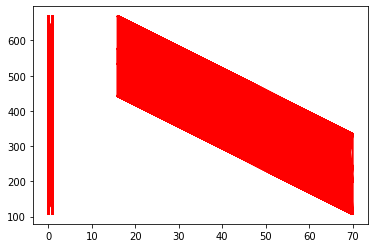

In [169]:
Y_pred = regression_model.predict(X_test) 
print(Y_pred)
#plt.scatter(X_test, y_test,  color='gray')
print(X_test.size)
print(y_test.size)


plt.plot(X_test, Y_pred, color='red', linewidth=2)
plt.show()


In [131]:
#so the linear regression equation we get is
#----loss in thousands=539.65-6.14*Age-1.79*Number of Vehicles+97*M+136*Single
#so according to above--
#Young people (- coeff)and Male(+ coeff) & Unmarried person(+coeff)
#dont pay their loans back
#lets get the P values of each predictors 
import statsmodels.api as sm
from statsmodels.api import add_constant
X2 = add_constant(X_train)
lm= sm.OLS(y_train,X2)
lm2=lm.fit()
lm2.pvalues
# sm.OLS by default does not add an intercept in the model.
#so we manually added it by the first line 

//anaconda3/lib/python3.7/site-packages/numpy/core/fromnumeric.py:2389: FutureWarning: Method .ptp is deprecated and will be removed in a future version. Use numpy.ptp instead.
  return ptp(axis=axis, out=out, **kwargs)


const              0.000000e+00
Age                0.000000e+00
Gender_M           3.968881e-85
Married_Single    3.219962e-176
dtype: float64

In [132]:
print(lm2.summary())

                             OLS Regression Results                            
Dep. Variable:     Losses in Thousands   R-squared:                       0.322
Model:                             OLS   Adj. R-squared:                  0.322
Method:                  Least Squares   F-statistic:                     1210.
Date:                 Sun, 17 Nov 2019   Prob (F-statistic):               0.00
Time:                         06:46:49   Log-Likelihood:                -51460.
No. Observations:                 7645   AIC:                         1.029e+05
Df Residuals:                     7641   BIC:                         1.030e+05
Df Model:                            3                                         
Covariance Type:             nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const            541.2123      6.7

In [134]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn import linear_model

poly = PolynomialFeatures(degree=2, interaction_only=True)
X_train2 = poly.fit_transform(X_train)
X_test2 = poly.fit_transform(X_test)

poly_clf = linear_model.LinearRegression()

poly_clf.fit(X_train2, y_train)

y_pred = poly_clf.predict(X_test2)

print(y_pred)

#In sample (training) R^2 will always improve with the number of variables!
print(poly_clf.score(X_train2, y_train))

[[509.15156769]
 [500.69066592]
 [330.17467827]
 ...
 [503.44760428]
 [303.09521338]
 [463.51986042]]
0.3737346556034282


In [ ]:
print('Coefficients: \n', regr.coef_)
# The mean squared error
print("Mean squared error: %.2f"
      % mean_squared_error(diabetes_y_test, diabetes_y_pred))
# Explained variance score: 1 is perfect prediction
print('Variance score: %.2f' % r2_score(diabetes_y_test, diabetes_y_pred))

# Plot outputs
plt.scatter(diabetes_X_test, diabetes_y_test,  color='black')
plt.plot(diabetes_X_test, diabetes_y_pred, color='blue', linewidth=3)

plt.xticks(())
plt.yticks(())

plt.show()